# Monte Carlo Methods

## (Pseudo) Random Numbers

### Linear congruential generator (LCG)
To test the quality of a random number generator, (i) we first make sure it has a long-enough period (for LCB, the period is $\le m$). (ii) We make scatter plot for $u_i$ and $u_{i-1}$ (i.e. two consecutively generated random numbers) and see if they are uniformly, randomly distributed. (iii) We make historgram plot to check the event distribution in each bin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, '$u_i$')

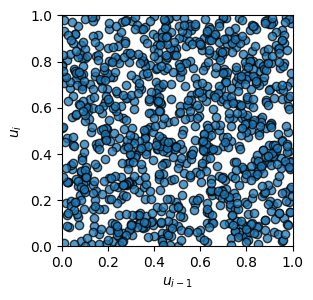

In [2]:
#The following set of (a,c,m) is used in C++11.
def lcg(seed,a=48271,c=0,m=2**31-1):
    return (a*seed +c)%m

n=1000

#For later use to rescale ri = ui/m
m=2**31-1

u_list=[]    

seed = 6
for i in range(n):
    u_list.append(lcg(seed)/m)
    seed=lcg(seed)

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(u_list[0:-1],u_list[1:], alpha=0.75, edgecolors='k')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect(1)
ax.set_xlabel('$u_{i-1}$')
ax.set_ylabel('$u_i$')

Text(0, 0.5, 'No. of Events')

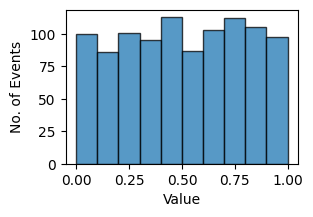

In [3]:
fig, ax = plt.subplots(figsize=(3,2))

ax.hist(u_list, bins=10, alpha=0.75, edgecolor='k')
ax.set_xlabel('Value')
ax.set_ylabel('No. of Events')

### Random number generator in Python

In [4]:
print(np.random.random())

#create a list of 3 random numbers:
rlist=np.random.random(3)
print(rlist)

#In the above cases, the random number being
#generated varies every time when the function is called.

0.7929550409678802
[0.17967241 0.55624779 0.28630901]


In [5]:
#set the random seed, by
#using the default generator PCG64 (period = 2**128).
rng = np.random.default_rng(seed=0)

print(rng.random())
print(rng.random(1))
print(rng.random(3))

#By fixing the random seed, the
#pseudo-random numbers can be reproduced every time.

0.6369616873214543
[0.26978671]
[0.04097352 0.01652764 0.81327024]


Text(0, 0.5, '$u_i$')

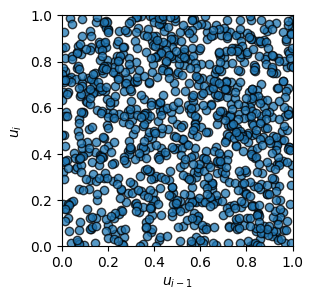

In [6]:
n= 1000
rng = np.random.default_rng(seed=0)
u_list = rng.random(n)

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(u_list[0:-1],u_list[1:], alpha=0.75, edgecolors='k')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect(1)
ax.set_xlabel('$u_{i-1}$')
ax.set_ylabel('$u_i$')

Text(0, 0.5, 'No. of Events')

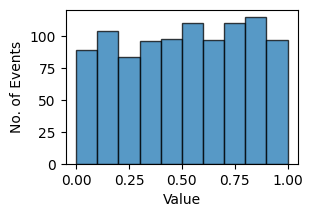

In [7]:
fig, ax = plt.subplots(figsize=(3,2))

ax.hist(u_list, bins=10, alpha=0.75, edgecolor='k')
ax.set_xlabel('Value')
ax.set_ylabel('No. of Events')

### Estimate the value of $\pi$ 

In [8]:
n = 10**3

xlist=[]
ylist=[]
N_in=[]

rng = np.random.default_rng(seed=0)

for ii in range(n):

    x, y = rng.random(2)
    xlist.append(x)
    ylist.append(y)
    
    r = (x**2+y**2)**0.5

    if r<=1.0: 
        N_in.append(1)
    else:
        N_in.append(0)

pi_estimate = float(sum(N_in))/float(n)*4

print('pi ~',pi_estimate)
print('error = ', pi_estimate - np.pi)

pi ~ 3.244
error =  0.1024073464102071


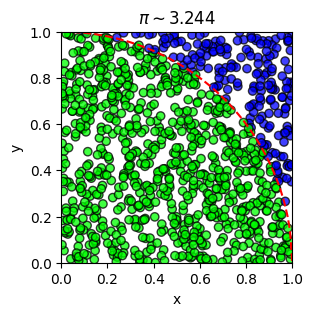

In [9]:
x = np.linspace(0,1,100)
y = np.sqrt(1-x**2)

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(x,y,c='r',ls='--')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect(1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'$\pi\sim$'+str(pi_estimate))

import matplotlib.cm as cm
ax.scatter(xlist,ylist,c=N_in,cmap=cm.brg,alpha=0.75, edgecolors='k')

## Monte Carlo Integration

**Example.** Use a uniform Monte Carlo sampling to evaluate the integral
$I\equiv \int^{10}_0 e^{-x}(x^3+1)dx$.

Finite difference step size h = 0.001
Integral value from trapezoid rule: 6.937938376695911
Exact value =  6.937938296014683
Absolute error =  8.068122792082022e-08


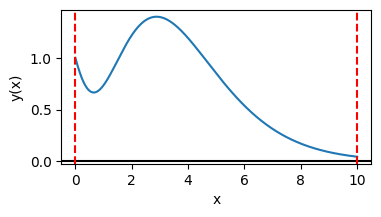

In [10]:
#First visualize the function:
n=10001
a = 0
b = 10
h = (b-a)/(n-1)
print('Finite difference step size h =',h)

x = np.linspace(a,b,n)
y = np.exp(-x)*(x**3+1)

fig, ax = plt.subplots(figsize=(4,2))
ax.plot(x,y)
ax.set_xlabel('x')
ax.set_ylabel('y(x)')
ax.axhline(y=0,c='k',ls='-')
ax.axvline(x=0,c='r', ls='--')
ax.axvline(x=10,c='r', ls='--')

I_exact = 7-1367/np.e**10

#Trapezoid Rule as a Benchmark:
#numpy.trapezoid(y, x=None, dx=1.0, axis=-1)
print('Integral value from trapezoid rule:', np.trapezoid(y, x))
print('Exact value = ', I_exact)
print('Absolute error = ',abs(np.trapezoid(y, x)-I_exact))

In [12]:
#Monte Carlo Integration:
def f(x):
    return np.exp(-x)*(x**3+1)

def MCintegration(n=100, a=0, b=10):

    rng = np.random.default_rng(seed=0)
    
    fsum = 0
    for i in range(n):

        xi = rng.random()
        #Rescale it s.t. xi is between [a,b):
        xi = a+ (b-a)*xi
    
        fsum = fsum+ f(xi)

    fsum = (b-a)/n*fsum
    return fsum

n=10**6
I_MC = MCintegration(n)

I_exact = 7-1367/np.e**10

print('Number of MC sampling points =', n)
print('Absolute error =', abs(I_MC - I_exact))

Number of MC sampling points = 1000000
Absolute error = 0.003223496266797632


Text(0.5, 1.0, 'Monte Carlo integration')

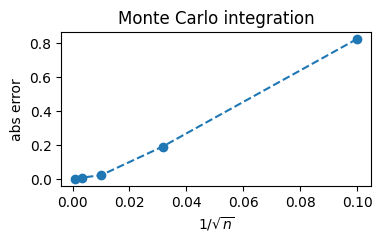

In [13]:
nlist=[10**2,10**3,10**4,10**5,10**6]
elist=[]

I_exact = 7-1367/np.e**10

for n in nlist:
    error = abs(MCintegration(n)-I_exact)
    elist.append(error)
      
narray=np.array(nlist)
earray=np.array(elist)

fig, ax = plt.subplots(figsize=(4,2))
ax.plot(1/np.sqrt(narray),earray,'--o')

ax.set_xlabel(r'$1/\sqrt{n}$')
ax.set_ylabel('abs error')
ax.set_title('Monte Carlo integration')

### Inverse Transform Sampling

**Example.** Use inverse transform sampling to evaluate the integral $I \equiv \int^1_0 e^{-x}\cos(x) dx \equiv \int^1_0 w(x) f(x) dx$, with the change of variable $du(x) = w(x) dx = e^{-x} dx$.

In [14]:
# Method 1: A direct, uniform Monte Carlo sampling on xi:
def f(x):
    return np.exp(-x)*np.cos(x)

n=10**3
I_MC = MCintegration(n, a=0, b=1)

I_exact = (np.e + np.sin(1)-np.cos(1))/2/np.e

print('Direct MC sampling')
print('Number of MC sampling points =', n)
print('Absolute error = ',abs(I_MC - I_exact))

Direct MC sampling
Number of MC sampling points = 1000
Absolute error =  0.014299990999926182


In [15]:
# Method 2: An inverse transform sampling,
# then a uniform sampling on ui:
def f(u):
    c = np.e/(np.e-1)
    return np.cos(-np.log(1-u/c))/c

n=10**3
I_MC = MCintegration(n,a=0, b=1)

I_exact = (np.e + np.sin(1)-np.cos(1))/2/np.e

print('Inverse transform MC sampling')
print('Number of MC sampling points =', n)
print('Absolute error = ',abs(I_MC - I_exact))

Inverse transform MC sampling
Number of MC sampling points = 1000
Absolute error =  0.0034183400243041895


**Note:** As seen from the above example, with the same number of samping points, an inverse transform sampling is more accurate than a direct uniform sampling.

### Importance Sampling

**Example.** Use importance sampling to evaluate the integral $I \equiv \int^1_0 \frac1{\sqrt{x^2+1}} dx = \int^1_0 f(x) dx = \int^1_0 w(x)\frac{f(x)}{w(x)} dx$. Here, use the weighting function $w(x) = c_0 + c_1 x$, where $c_0 = 4-2\sqrt{2}$ and $c_1 = -6+4\sqrt{2}$.

In [16]:
# Method 1: A direct, uniform Monte Carlo sampling on xi:
def f(x):
    return 1/np.sqrt(x**2+1)

n=10**3
I_MC = MCintegration(n, a=0, b=1)

I_exact = np.arcsinh(1)
#I_exact = 0.88137358701954

print('Direct MC sampling')
print('Number of MC sampling points =', n)
print('Absolute error = ',abs(I_MC - I_exact))

Direct MC sampling
Number of MC sampling points = 1000
Absolute error =  0.005164539046282224


In [17]:
# Method 2: An importance sampling,
# then an inverse transform sampling,
# then a uniform sampling on ui:
def f(u):
    c0=4-2*np.sqrt(2)
    c1=-6+4*np.sqrt(2)
    x=1/c1*(-c0+np.sqrt(c0**2+2*c1*u))
    
    return 1/np.sqrt(x**2+1)*1/(c0+c1*x) # f(u)/w(u)

n=10**3
I_MC = MCintegration(n, a=0, b=1)

I_exact = np.arcsinh(1)
#I_exact = 0.88137358701954

print('Importance MC sampling with inverse transform')
print('Number of MC sampling points =', n)
print('Absolute error = ',abs(I_MC - I_exact))

Importance MC sampling with inverse transform
Number of MC sampling points = 1000
Absolute error =  5.874596495358819e-05


**Note:** As seen from the above example, with the same number of samping points, an importance sampling (with inverse transform) is more accurate than a direct uniform sampling.

## Markov-Chain Monte Carlo (MCMC)

**Example.** Use Monte Carlo sampling methods to evaluate the integral 
$I\equiv \int^{10}_0 e^{-x}\cos(x) dx$.

In [ ]:
#Plot the function:
def f(x):
    return np.exp(-x)*np.cos(x)

a=0
b=10
n=1001
h=(b-a)/(n-1)

x = np.linspace(a,b,n)

fig, ax = plt.subplots(figsize=(4,2))

ax.plot(x,f(x))
ax.set_xlabel('x')
ax.set_ylabel('y')

In [ ]:
# A direct, uniformt Monte Carlo sampling:
def f(x):
    return np.exp(-x)*np.cos(x)
    
n= 10000

import time
start_time = time.time()

I_MC = MCintegration(n,a=0,b=10)
I_exact = 0.5*(1+(np.sin(10)-np.cos(10))/np.exp(10))

end_time = time.time()

print('Time spent on MC integration (sec):', end_time - start_time)
print('Number of MC sampling points = ', n)
print('I_MC = ', I_MC)
print('Absolute error = ', abs(I_MC - I_exact))

### MCMC using the Metropolis Algorithm

**Example.** $I\equiv \int^\infty_0 e^{-x}\cos(x) dx \equiv \int^\infty_0 w(x)f(x) dx$.

In [ ]:
#MCMC Integration:

# Setting MCM parameters:
#============================
n_burnin=10**4
measurement_step = 10
n_measurement = 10000

#n_burnin = 0
#measurement_step = 1
#n_measurement = 100

#Total number of steps:
n_MC = n_burnin + n_measurement*measurement_step

# Adjust the learning rate "theta", 
# so that the acceptance rate is ~ 0.15 to 0.5:
theta = 3.0
#============================

def w(x):
    if x <0:
        return 0
    else:
        return np.exp(-x)

def f(x):
    return np.cos(x)

#Pick a random starting position (with a nonzero probability):
x0 = 1.0
xx=[]
xx.append(x0)
    
#Initialize a random number generator:
rng = np.random.default_rng(seed=0)

count=0
mcount=0
summation=0

import time
start_time = time.time()

for i in range(0, n_MC):

    #Proposed move to x1:
    x1 = x0 + theta*rng.uniform(-1,1)

    if w(x1) == 0:
        x0=x0
        
    else:        
        
        ratio = w(x1)/w(x0)
    
        if ratio >= 1: #accept the move
            x0=x1
            count=count+1
        else:
            r = rng.random()
            if r <= ratio: #accept the move
                x0=x1
                count=count+1
            else: #reject the move
                x0=x0
            
    xx.append(x0)

    #For measurements (to evaluate the integral)
    if (i>=n_burnin) and (i%measurement_step==0):
        mcount=mcount+1
        summation=summation + f(x0)

end_time = time.time()

I_MCMC = summation/mcount
I_exact = 0.5

print('MCMC time spent(sec):',end_time-start_time)
print('Total random walks:', n_MC)
print('Number of measurements:', mcount)
print('Acceptance rate:', count/n_MC)
print('I_MCMC=',I_MCMC)
print('Absolute error = ', abs(I_MCMC - I_exact))

In [ ]:
# Visualization the resulting sampling distribution of xi:
a=0
b=10
n=1001
h=(b-a)/(n-1)

x = np.linspace(a,b,n)

def w(x):
    return np.exp(-x)

def f(x):
    return np.cos(x)

fig, ax = plt.subplots(figsize=(6,3))

ax.plot(x,w(x)*f(x), lw=2, label=r'$w(x)f(x)=e^{-x}\cos(x)$')
ax.plot(x, w(x), color='r', ls='--', lw=2, label=r'$w(x)=e^{-x}$')

#Actual sampling points distribution from the Metropolis algorithm:
#If "density" is True, the weights are normalized.
hist=plt.hist(np.array(xx),bins=101,density=True,alpha=0.6, label='MCMC sampling distribution.')

ax.legend()
ax.set_xlim(0,10)
ax.set_xlabel('x')
ax.set_ylabel('y')

**Final Remark:** The Metropolis algorithm (developed in 1946 by Nicholas Metropolis) is often regarded as the No. 1 algorithm in the **Top 10 most important algorithms of the 20th century**. Essentially, it enables the sampling of any analytical function you choose.